In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv("/content/census_income.csv")
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [3]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [4]:
df.replace([" ","?"], np.nan, inplace=True)

In [5]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [6]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'annual_income'],
      dtype='object')

In [7]:
cols=['workclass','occupation','native-country']
for i in cols:
  df[i].fillna(df[i].mode()[0],inplace=True)

In [8]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [9]:
df.duplicated().sum()

np.int64(24)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32537 non-null  int64 
 1   workclass       32537 non-null  object
 2   fnlwgt          32537 non-null  int64 
 3   education       32537 non-null  object
 4   education-num   32537 non-null  int64 
 5   marital-status  32537 non-null  object
 6   occupation      32537 non-null  object
 7   relationship    32537 non-null  object
 8   race            32537 non-null  object
 9   sex             32537 non-null  object
 10  capital-gain    32537 non-null  int64 
 11  capital-loss    32537 non-null  int64 
 12  hours-per-week  32537 non-null  int64 
 13  native-country  32537 non-null  object
 14  annual_income   32537 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.0+ MB


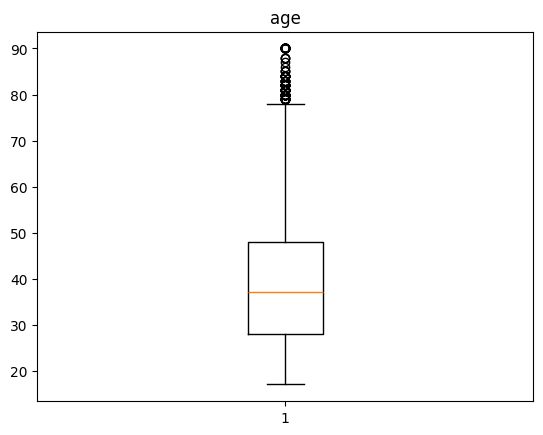

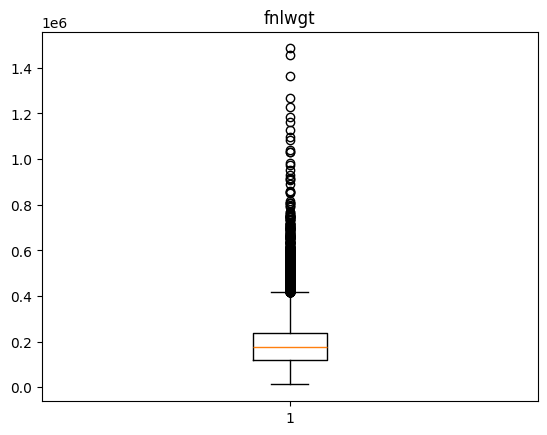

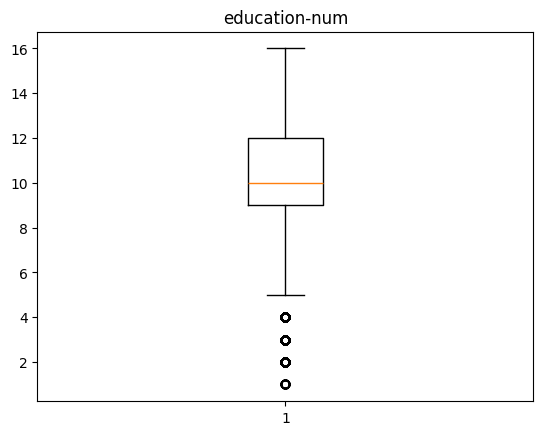

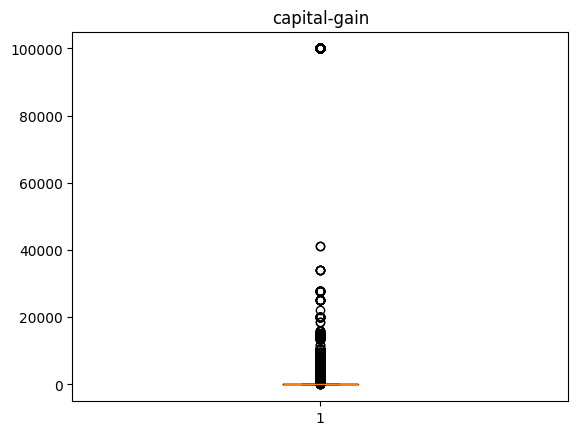

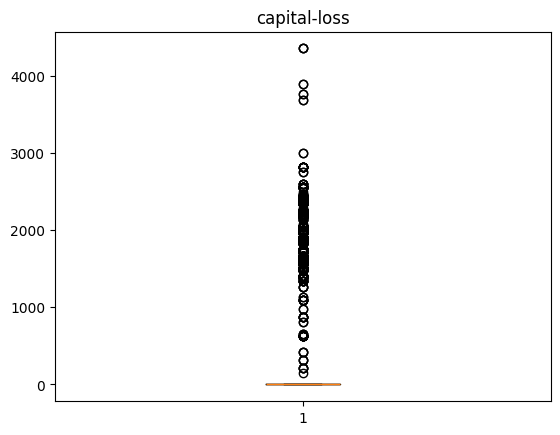

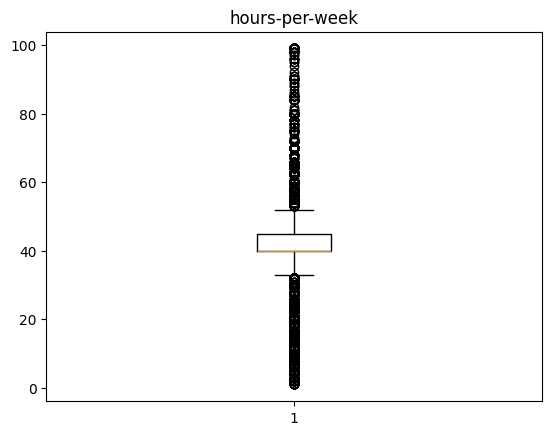

In [13]:
for i in df.columns:
  if(df[i].dtype != "object"):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
le = LabelEncoder()
for i in df.columns:
  if(df[i].dtype=='object'):
    df[i] = le.fit_transform(df[i])

In [14]:
from sklearn.ensemble import AdaBoostClassifier

In [17]:
df['annual_income'].value_counts()

,count
annual_income,
0,24698
1,7839


In [18]:
x = df.drop(columns='annual_income')

In [20]:
y=df['annual_income']

In [21]:
x

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,6,77516,9,13,4,0,1,4,1,2174,0,40,38
1,50,5,83311,9,13,2,3,0,4,1,0,0,13,38
2,38,3,215646,11,9,0,5,1,4,1,0,0,40,38
3,53,3,234721,1,7,2,5,0,2,1,0,0,40,38
4,28,3,338409,9,13,2,9,5,2,0,0,0,40,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,3,257302,7,12,2,12,5,4,0,0,0,38,38
32557,40,3,154374,11,9,2,6,0,4,1,0,0,40,38
32558,58,3,151910,11,9,6,0,4,4,0,0,0,40,38
32559,22,3,201490,11,9,4,0,3,4,1,0,0,20,38


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
model1 = LogisticRegression()

In [26]:
model1.fit(x_train,y_train)

LogisticRegression()

In [27]:
y_pred = model1.predict(x_test)

In [28]:
from sklearn.metrics import accuracy_score

In [29]:
accuracy_score(y_test, y_pred)

0.7897971727105101

In [30]:
from sklearn.tree import DecisionTreeClassifier

In [31]:
model2 = DecisionTreeClassifier()

In [32]:
model2.fit(x_train,y_train)

DecisionTreeClassifier()

In [33]:
y_pred1 = model2.predict(x_test)

In [34]:
accuracy_score(y_test, y_pred1)

0.8068531038721574

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
model3 = RandomForestClassifier()

In [37]:
model3.fit(x_train, y_train)

RandomForestClassifier()

In [38]:
y_pred2 = model3.predict(x_test)

In [39]:
accuracy_score(y_test,y_pred2)

0.8592501536570375

In [40]:
from sklearn.ensemble import AdaBoostClassifier

In [41]:
model4 = AdaBoostClassifier()

In [42]:
model4.fit(x_train,y_train)

AdaBoostClassifier()

In [43]:
y_pred3 = model4.predict(x_test)

In [44]:
accuracy_score(y_test,y_pred3)

0.854179471419791

In [45]:
model5 = AdaBoostClassifier(n_estimators=100, learning_rate=1, random_state=42)

In [46]:
model5.fit(x_train,y_train)

AdaBoostClassifier(learning_rate=1, n_estimators=100, random_state=42)

In [47]:
y_pred4 = model5.predict(x_test)

In [48]:
accuracy_score(y_test,y_pred4)

0.8597111247695144